# State-Action Value Function: Campus Delivery Drone

**Topic:** Reinforcement Learning, the state-action value function `Q(s, a)`

**Scenario:** A delivery drone flies along a straight corridor of 8 landing pads (states 0 to 7).

- Pad 0 is the **Charging Dock** (terminal state, reward = 60)
- Pad 7 is the **Customer Drop-off** (terminal state, reward = 100)
- Pads 1 to 6 are normal pads. Every move costs a small battery penalty (step reward)
- At each normal pad the drone can choose **Left** or **Right**
- Wind can push the drone the wrong way with probability `misstep_prob`

**Goal of this notebook:** see how `Q(s, a)` and the best policy change when we change the rewards, the discount factor `gamma`, and the wind (`misstep_prob`).

You can change the values in the "Parameters" cell and re-run everything below it.

## 1. Key ideas

**Return:** the sum of discounted rewards the drone collects:

`Return = R1 + gamma * R2 + gamma^2 * R3 + ...`

**State-action value function:** `Q(s, a)` is the return you get if you

1. start in state `s`,
2. take action `a` once (even if it is not the best action),
3. and then behave optimally after that.

**Bellman equation:**

`Q(s, a) = R(s) + gamma * sum over s' of  P(s' | s, a) * max over a' of Q(s', a')`

**Best policy:** in every state pick the action with the larger Q value:

`pi(s) = argmax over a of Q(s, a)`

For terminal states there is no future, so `Q(s, a) = R(s)` for both actions.

## 2. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=2, suppress=True)

## 3. Environment setup (do not modify)

In [2]:
NUM_STATES = 8
NUM_ACTIONS = 2

LEFT, RIGHT = 0, 1
ACTION_NAMES = ["Left", "Right"]

TERMINAL_LEFT = 0
TERMINAL_RIGHT = NUM_STATES - 1
TERMINAL_STATES = [TERMINAL_LEFT, TERMINAL_RIGHT]

STATE_LABELS = ["Dock"] + [f"Pad {i}" for i in range(1, NUM_STATES - 1)] + ["Customer"]
print(STATE_LABELS)

['Dock', 'Pad 1', 'Pad 2', 'Pad 3', 'Pad 4', 'Pad 5', 'Pad 6', 'Customer']


## 4. Parameters (play with these)

Try changing one value at a time and re-run the notebook from here.

In [3]:
# Rewards
charging_dock_reward = 60      # terminal state on the left
customer_reward = 100          # terminal state on the right
each_step_reward = -1          # battery cost for every move on a normal pad

# Discount factor: 0 means only care about now, close to 1 means care about the far future
gamma = 0.9

# Probability that wind pushes the drone in the opposite direction
misstep_prob = 0.1

## 5. Build the model

First we build the transition probabilities `P[s, a, s']` and the reward vector `R[s]`.

In [4]:
def build_rewards(left_reward, right_reward, step_reward):
    """Reward for being in each state."""
    R = np.full(NUM_STATES, float(step_reward))
    R[TERMINAL_LEFT] = left_reward
    R[TERMINAL_RIGHT] = right_reward
    return R


def build_transitions(misstep_prob):
    """
    P[s, a, s2] = probability of landing on pad s2 after choosing action a in state s.
    Terminal states have no transitions (all zeros).
    """
    P = np.zeros((NUM_STATES, NUM_ACTIONS, NUM_STATES))
    for s in range(NUM_STATES):
        if s in TERMINAL_STATES:
            continue
        for a in range(NUM_ACTIONS):
            intended = s - 1 if a == LEFT else s + 1
            wrong = s + 1 if a == LEFT else s - 1
            P[s, a, intended] += 1 - misstep_prob
            P[s, a, wrong] += misstep_prob
    return P


# Quick sanity check: every non-terminal row must sum to 1
P_test = build_transitions(misstep_prob)
print("Transition from Pad 3 if we choose Right:")
print(P_test[3, RIGHT])
print("Row sums OK:", np.allclose(P_test[1:-1].sum(axis=2), 1.0))

Transition from Pad 3 if we choose Right:
[0.  0.  0.1 0.  0.9 0.  0.  0. ]
Row sums OK: True


## 6. Compute Q(s, a) using the Bellman equation

We start with all Q values at 0 and keep applying the Bellman equation until the numbers stop changing. This is called **value iteration**.

In [5]:
def compute_q(left_reward, right_reward, step_reward, gamma, misstep_prob,
              tol=1e-9, max_iter=10_000):
    """Return the converged Q table of shape (NUM_STATES, NUM_ACTIONS)."""
    assert 0 <= gamma < 1, "gamma must be in [0, 1) so that the values converge"
    assert 0 <= misstep_prob <= 1, "misstep_prob must be a probability"

    R = build_rewards(left_reward, right_reward, step_reward)
    P = build_transitions(misstep_prob)
    Q = np.zeros((NUM_STATES, NUM_ACTIONS))

    for i in range(max_iter):
        V = Q.max(axis=1)                       # best value of each next state
        Q_new = R[:, None] + gamma * (P @ V)    # Bellman update
        if np.abs(Q_new - Q).max() < tol:
            Q = Q_new
            break
        Q = Q_new
    return Q


Q = compute_q(charging_dock_reward, customer_reward, each_step_reward, gamma, misstep_prob)
Q

array([[ 60.  ,  60.  ],
       [ 52.01,  44.1 ],
       [ 46.17,  49.01],
       [ 44.54,  55.96],
       [ 51.09,  64.88],
       [ 59.36,  75.12],
       [ 68.84,  86.76],
       [100.  , 100.  ]])

In [6]:
def q_table(Q):
    """Pretty table with the best action for each state."""
    rows = []
    for s in range(NUM_STATES):
        if s in TERMINAL_STATES:
            best = "terminal"
        elif abs(Q[s, LEFT] - Q[s, RIGHT]) < 1e-9:
            best = "tie"
        else:
            best = ACTION_NAMES[int(np.argmax(Q[s]))]
        rows.append([STATE_LABELS[s], Q[s, LEFT], Q[s, RIGHT], Q[s].max(), best])
    df = pd.DataFrame(rows, columns=["State", "Q(s, Left)", "Q(s, Right)", "Q*(s) = max Q", "Best action"])
    return df.round(2)


q_table(Q)

,State,"Q(s, Left)","Q(s, Right)",Q*(s) = max Q,Best action
0,Dock,60.00,60.00,60.00,terminal
1,Pad 1,52.01,44.10,52.01,Left
2,Pad 2,46.17,49.01,49.01,Right
3,Pad 3,44.54,55.96,55.96,Right
4,Pad 4,51.09,64.88,64.88,Right
5,Pad 5,59.36,75.12,75.12,Right
6,Pad 6,68.84,86.76,86.76,Right
7,Customer,100.00,100.00,100.00,terminal


## 7. Visualize Q(s, a) and the best policy

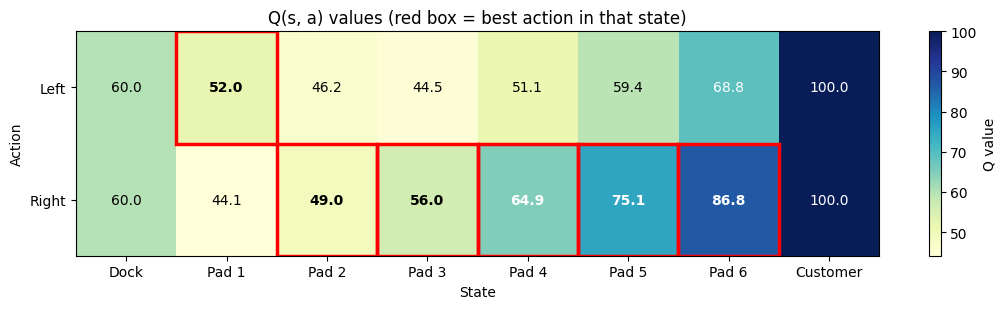

In [7]:
def plot_q(Q, title=None):
    fig, ax = plt.subplots(figsize=(11, 3.2))
    im = ax.imshow(Q.T, cmap="YlGnBu", aspect="auto")

    ax.set_xticks(range(NUM_STATES))
    ax.set_xticklabels(STATE_LABELS)
    ax.set_yticks(range(NUM_ACTIONS))
    ax.set_yticklabels(ACTION_NAMES)
    ax.set_xlabel("State")
    ax.set_ylabel("Action")

    for s in range(NUM_STATES):
        for a in range(NUM_ACTIONS):
            is_best = (s not in TERMINAL_STATES) and (Q[s, a] >= Q[s].max() - 1e-9)
            ax.text(s, a, f"{Q[s, a]:.1f}", ha="center", va="center",
                    fontsize=10, fontweight="bold" if is_best else "normal",
                    color="white" if Q[s, a] > Q.max() * 0.6 else "black")
            if is_best:
                ax.add_patch(plt.Rectangle((s - 0.5, a - 0.5), 1, 1,
                                           fill=False, edgecolor="red", linewidth=2.5))

    ax.set_title(title or "Q(s, a) values (red box = best action in that state)")
    fig.colorbar(im, ax=ax, label="Q value")
    plt.tight_layout()
    plt.show()


plot_q(Q)

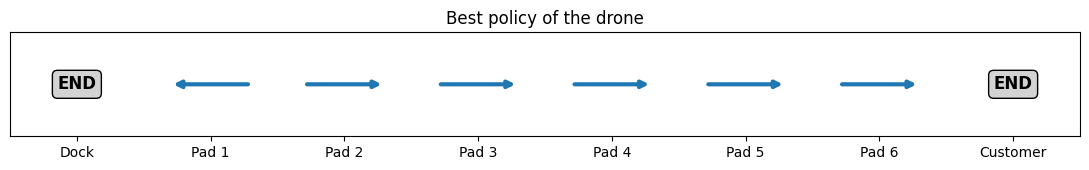

In [8]:
def plot_policy(Q):
    fig, ax = plt.subplots(figsize=(11, 1.8))
    ax.set_xlim(-0.5, NUM_STATES - 0.5)
    ax.set_ylim(-0.6, 0.6)
    ax.set_yticks([])
    ax.set_xticks(range(NUM_STATES))
    ax.set_xticklabels(STATE_LABELS)

    for s in range(NUM_STATES):
        if s in TERMINAL_STATES:
            ax.text(s, 0, "END", ha="center", va="center", fontsize=12, fontweight="bold",
                    bbox=dict(boxstyle="round", facecolor="lightgray"))
        elif abs(Q[s, LEFT] - Q[s, RIGHT]) < 1e-9:
            ax.text(s, 0, "tie", ha="center", va="center", fontsize=12)
        else:
            dx = -0.3 if np.argmax(Q[s]) == LEFT else 0.3
            ax.annotate("", xy=(s + dx, 0), xytext=(s - dx, 0),
                        arrowprops=dict(arrowstyle="-|>", lw=3, color="tab:blue"))
    ax.set_title("Best policy of the drone")
    plt.tight_layout()
    plt.show()


plot_policy(Q)

### How to read the results

- Look at a pad in the middle. `Q(s, Left)` and `Q(s, Right)` can be very different, and the bigger one decides the policy.
- Pads close to the Charging Dock usually prefer Left, because the smaller reward is reached sooner and is discounted less.
- Pads close to the Customer usually prefer Right.
- There is a **switch point** in the middle where the best action flips. The experiments below move this switch point.

## 8. Check the numbers by hand

Let us verify one Bellman equation manually for **Pad 3, action Right**, so we know the code is doing what the formula says.

In [9]:
R = build_rewards(charging_dock_reward, customer_reward, each_step_reward)
V = Q.max(axis=1)

s, a = 3, RIGHT
manual = R[s] + gamma * ((1 - misstep_prob) * V[s + 1] + misstep_prob * V[s - 1])

print(f"R(Pad 3)                     = {R[s]}")
print(f"max Q at Pad 4 (intended)    = {V[s + 1]:.4f}")
print(f"max Q at Pad 2 (wind)        = {V[s - 1]:.4f}")
print(f"Manual Q(Pad 3, Right)       = {manual:.4f}")
print(f"Code   Q(Pad 3, Right)       = {Q[s, a]:.4f}")
print("Match:", np.isclose(manual, Q[s, a]))

R(Pad 3)                     = -1.0
max Q at Pad 4 (intended)    = 64.8800
max Q at Pad 2 (wind)        = 49.0117
Manual Q(Pad 3, Right)       = 55.9638
Code   Q(Pad 3, Right)       = 55.9638
Match: True


## 9. Second check: simulate the drone (Monte Carlo)

`Q(s, a)` is an **expected** discounted return. If we really fly the drone many times (first action = `a`, then the best policy), the average discounted return should be close to `Q(s, a)`.

In [10]:
def simulate_return(Q, s, a, R, P, gamma, rng, max_steps=1000):
    """One episode: take action a in state s, then follow the greedy policy. Return discounted return."""
    total, discount = 0.0, 1.0
    state, action = s, a
    for _ in range(max_steps):
        total += discount * R[state]
        if state in TERMINAL_STATES:
            break
        discount *= gamma
        state = rng.choice(NUM_STATES, p=P[state, action])
        action = int(np.argmax(Q[state]))
    return total


def monte_carlo_q(Q, s, a, episodes=20_000, seed=0):
    rng = np.random.default_rng(seed)
    R = build_rewards(charging_dock_reward, customer_reward, each_step_reward)
    P = build_transitions(misstep_prob)
    returns = [simulate_return(Q, s, a, R, P, gamma, rng) for _ in range(episodes)]
    return np.mean(returns)


rows = []
for s in [1, 3, 5]:
    for a in [LEFT, RIGHT]:
        rows.append([STATE_LABELS[s], ACTION_NAMES[a], Q[s, a], monte_carlo_q(Q, s, a)])

pd.DataFrame(rows, columns=["State", "First action", "Q from Bellman", "Monte Carlo average"]).round(2)

,State,First action,Q from Bellman,Monte Carlo average
0,Pad 1,Left,52.01,52.02
1,Pad 1,Right,44.10,44.04
2,Pad 3,Left,44.54,44.47
3,Pad 3,Right,55.96,55.83
4,Pad 5,Left,59.36,59.27
5,Pad 5,Right,75.12,75.02


## 10. Experiments

Now the fun part. We change one thing at a time and watch how the best policy and the Q values react.

In [11]:
def policy_string(Q):
    """Compact policy for pads 1 to 6, for example 'L L R R R R'."""
    out = []
    for s in range(1, NUM_STATES - 1):
        if abs(Q[s, LEFT] - Q[s, RIGHT]) < 1e-9:
            out.append("=")
        else:
            out.append("L" if np.argmax(Q[s]) == LEFT else "R")
    return " ".join(out)


def sweep(param_name, values, **base):
    """Run compute_q for several values of one parameter and collect results."""
    results = {}
    rows = []
    for v in values:
        args = dict(base)
        args[param_name] = v
        Qv = compute_q(**args)
        results[v] = Qv
        rows.append([v, policy_string(Qv)] + list(Qv.max(axis=1)[1:-1].round(1)))
    cols = [param_name, "Policy (Pad 1..6)"] + [f"Q*(Pad {i})" for i in range(1, NUM_STATES - 1)]
    return pd.DataFrame(rows, columns=cols), results


base = dict(left_reward=charging_dock_reward, right_reward=customer_reward,
            step_reward=each_step_reward, gamma=gamma, misstep_prob=misstep_prob)
print("Base setup:", base)

Base setup: {'left_reward': 60, 'right_reward': 100, 'step_reward': -1, 'gamma': 0.9, 'misstep_prob': 0.1}


### Experiment A: change the discount factor `gamma`

Small gamma means the drone is impatient, so it prefers whatever reward is closest. Large gamma means it is patient and can aim for the far but bigger reward.

In [12]:
df_gamma, res_gamma = sweep("gamma", [0.3, 0.5, 0.7, 0.9, 0.99], **{k: v for k, v in base.items() if k != "gamma"})
df_gamma

,gamma,Policy (Pad 1..6),Q*(Pad 1),Q*(Pad 2),Q*(Pad 3),Q*(Pad 4),Q*(Pad 5),Q*(Pad 6)
0,0.30,L L L R R R,15.3,3.1,-0.1,0.6,6.1,26.2
1,0.50,L L L R R R,26.6,11.2,4.4,8.1,19.6,45.0
2,0.70,L L R R R R,38.5,24.5,17.4,26.5,41.8,64.9
3,0.90,L R R R R R,52.0,49.0,56.0,64.9,75.1,86.8
4,0.99,R R R R R R,83.0,87.6,90.2,92.6,95.1,97.5


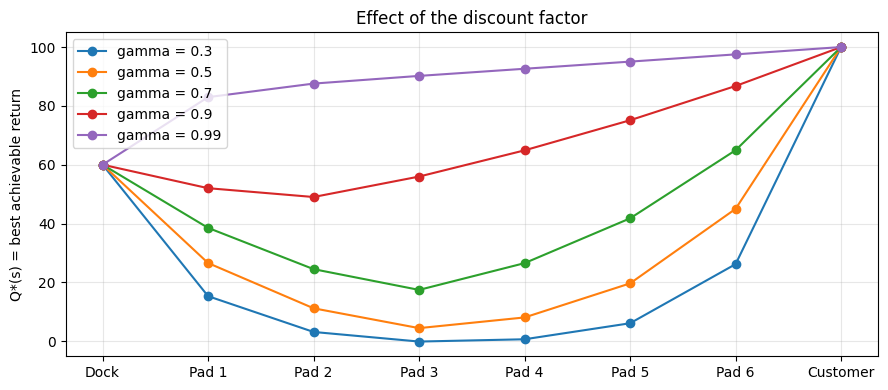

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
for g, Qg in res_gamma.items():
    ax.plot(range(NUM_STATES), Qg.max(axis=1), marker="o", label=f"gamma = {g}")
ax.set_xticks(range(NUM_STATES))
ax.set_xticklabels(STATE_LABELS)
ax.set_ylabel("Q*(s) = best achievable return")
ax.set_title("Effect of the discount factor")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Experiment B: change the step reward (battery cost)

A bigger penalty per move pushes the drone to finish quickly, even if the final reward is smaller.

In [14]:
df_step, res_step = sweep("step_reward", [0, -1, -3, -6, -10], **{k: v for k, v in base.items() if k != "step_reward"})
df_step

,step_reward,Policy (Pad 1..6),Q*(Pad 1),Q*(Pad 2),Q*(Pad 3),Q*(Pad 4),Q*(Pad 5),Q*(Pad 6)
0,0,L R R R R R,53.4,53.4,59.9,68.1,77.4,88.0
1,-1,L R R R R R,52.0,49.0,56.0,64.9,75.1,86.8
2,-3,L L R R R R,49.3,41.3,48.1,58.5,70.6,84.4
3,-6,L L R R R R,45.7,34.3,36.8,49.0,63.8,80.7
4,-10,L L R R R R,40.9,25.0,21.7,36.3,54.8,75.9


### Experiment C: change the wind `misstep_prob`

With more wind, long trips become risky, so the drone tends to prefer the nearer terminal state.

In [15]:
df_wind, res_wind = sweep("misstep_prob", [0.0, 0.1, 0.2, 0.3, 0.4], **{k: v for k, v in base.items() if k != "misstep_prob"})
df_wind

,misstep_prob,Policy (Pad 1..6),Q*(Pad 1),Q*(Pad 2),Q*(Pad 3),Q*(Pad 4),Q*(Pad 5),Q*(Pad 6)
0,0.0,L R R R R R,53.0,55.0,62.2,70.2,79.1,89.0
1,0.1,L R R R R R,52.0,49.0,56.0,64.9,75.1,86.8
2,0.2,L L R R R R,50.1,43.8,48.5,57.8,69.5,83.5
3,0.3,L L R R R R,47.6,39.9,40.6,48.9,61.8,78.7
4,0.4,L L R R R R,43.7,34.1,31.9,38.2,51.4,71.5


### Experiment D: change the terminal rewards

What happens if the Charging Dock becomes much more valuable (for example the drone is almost out of battery)?

In [16]:
df_dock, res_dock = sweep("left_reward", [20, 40, 60, 80, 100], **{k: v for k, v in base.items() if k != "left_reward"})
df_dock

,left_reward,Policy (Pad 1..6),Q*(Pad 1),Q*(Pad 2),Q*(Pad 3),Q*(Pad 4),Q*(Pad 5),Q*(Pad 6)
0,20,R R R R R R,39.5,47.8,55.8,64.9,75.1,86.8
1,40,R R R R R R,41.5,48.0,55.9,64.9,75.1,86.8
2,60,L R R R R R,52.0,49.0,56.0,64.9,75.1,86.8
3,80,L L R R R R,69.2,60.2,57.1,65.0,75.1,86.8
4,100,L L L R R R,86.8,75.2,65.8,65.8,75.2,86.8


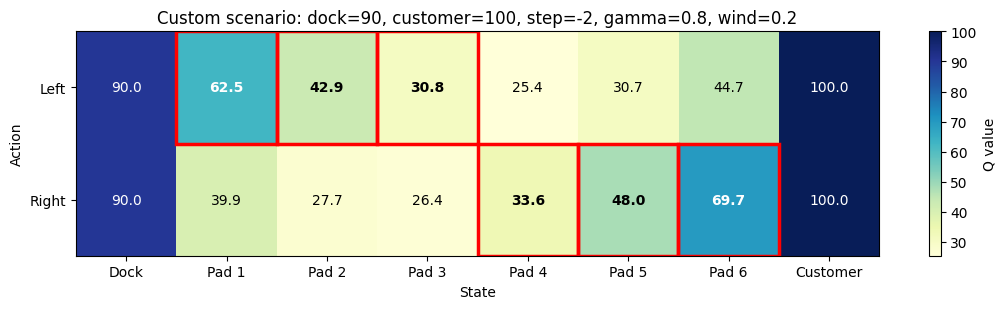

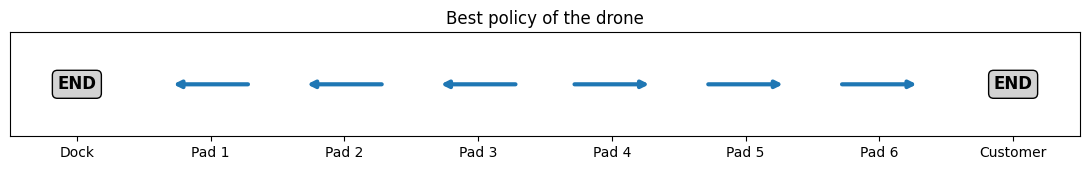

,State,"Q(s, Left)","Q(s, Right)",Q*(s) = max Q,Best action
0,Dock,90.00,90.00,90.00,terminal
1,Pad 1,62.47,39.86,62.47,Left
2,Pad 2,42.91,27.74,42.91,Left
3,Pad 3,30.85,26.40,30.85,Left
4,Pad 4,25.42,33.64,33.64,Right
5,Pad 5,30.68,47.97,47.97,Right
6,Pad 6,44.70,69.68,69.68,Right
7,Customer,100.00,100.00,100.00,terminal


In [17]:
# Visualize one custom scenario of your choice
Q_custom = compute_q(left_reward=90, right_reward=100, step_reward=-2, gamma=0.8, misstep_prob=0.2)
plot_q(Q_custom, title="Custom scenario: dock=90, customer=100, step=-2, gamma=0.8, wind=0.2")
plot_policy(Q_custom)
q_table(Q_custom)

## 11. Summary of what I learned

1. `Q(s, a)` tells us how good it is to take action `a` in state `s` and then act optimally.
2. The best policy is simply `argmax over a of Q(s, a)` in every state.
3. Q values are found by repeatedly applying the **Bellman equation** until they converge.
4. **Discount factor:** small gamma makes the agent short-sighted, large gamma makes it plan far ahead.
5. **Step reward:** a stronger penalty per move encourages finishing quickly.
6. **Randomness (misstep probability):** more uncertainty makes long, risky paths less attractive.
7. **Terminal rewards:** changing them moves the switch point where the best action flips.
8. The Monte Carlo simulation matched the Bellman values, so the theory and the code agree.

## 12. Practice questions

- Set `gamma = 0`. What does the policy look like and why?
- Find a combination of parameters where **every** pad chooses Left.
- Find a combination where every pad chooses Right.
- What happens to the Q values if `misstep_prob = 0.5`? Is the action still meaningful?
- Extend the environment to 12 pads. Where does the switch point move?
- Add a third action "Stay" that costs a step but never moves. When would it ever be optimal?

*Notebook written as part of my Reinforcement Learning practice (state-action value function).*